# 08 — Generate paper figures

Generate publication figures from finalized geometry, waveform, measurement, and array-analysis products. This notebook performs visualization only and does not recompute scientific measurements.


# Part I — Figure 1: deployment geometry


## 1. Imports and project paths

The notebook may be run from either the project root or the `notebooks/`
directory.


In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from pyproj import CRS, Geod, Transformer

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from project_config import ensure_output_dirs
from geometry_products import read_geometry_products
from figure1_utils import (
    get_sensor_location,
    make_figure1,
    save_figure,
)

PATHS = ensure_output_dirs(PROJECT_ROOT)
DERIVED_DIR = PATHS["derived"]
FIGURE_DIR = PATHS["figures"]

WGS84 = CRS.from_epsg(4326)
UTM17N = CRS.from_epsg(32617)

geod = Geod(ellps="WGS84")
ll_to_utm = Transformer.from_crs(
    WGS84,
    UTM17N,
    always_xy=True,
)
utm_to_ll = Transformer.from_crs(
    UTM17N,
    WGS84,
    always_xy=True,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Derived data: {DERIVED_DIR}")
print(f"Figure output: {FIGURE_DIR}")


Project root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper
Derived data: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/derived
Figure output: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/figures


## 2. Load the standardized geometry products

Notebook 02 writes the event inventory and normalized channel, station, and
KML-location tables. Figure 1 consumes those products directly rather than
rereading StationXML or KML independently.


In [8]:
(
    inventory_event,
    channels_df,
    stations_df,
    locations_df,
) = read_geometry_products(DERIVED_DIR)

print("Channel columns:")
print(channels_df.columns.tolist())

print("\nLocation columns:")
print(locations_df.columns.tolist())

display(stations_df)
display(channels_df)
display(locations_df)


Channel columns:
['network', 'station', 'location', 'channel', 'seed_id', 'latitude', 'longitude', 'elevation_m', 'depth_m', 'azimuth_deg', 'dip_deg', 'sample_rate_hz', 'sensor_description', 'channel_start', 'channel_end', 'station_latitude', 'station_longitude', 'station_elevation_m']

Location columns:
['kml_id', 'name', 'lat', 'lon', 'altitude_m']


,network,station,latitude,longitude,elevation_m,site_name,station_start,station_end,n_channels
0,1R,BCHH,28.574222,-80.572417,0.0,BCHH_SITE,2016-05-17,2016-10-06,6


,network,station,location,channel,seed_id,latitude,longitude,elevation_m,depth_m,azimuth_deg,dip_deg,sample_rate_hz,sensor_description,channel_start,channel_end,station_latitude,station_longitude,station_elevation_m
0,1R,BCHH,10,DD1,1R.BCHH.10.DD1,28.574222,-80.572417,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
1,1R,BCHH,10,DD2,1R.BCHH.10.DD2,28.573881,-80.572296,0.0,0.0,90.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
2,1R,BCHH,10,DD3,1R.BCHH.10.DD3,28.574006,-80.572560,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
3,1R,BCHH,10,DHE,1R.BCHH.10.DHE,28.574017,-80.572376,0.0,0.0,90.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
4,1R,BCHH,10,DHN,1R.BCHH.10.DHN,28.574017,-80.572376,0.0,0.0,0.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
5,1R,BCHH,10,DHZ,1R.BCHH.10.DHZ,28.574017,-80.572376,0.0,0.0,0.0,-90.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0


,kml_id,name,lat,lon,altitude_m
0,NE Tower,NE Tower,28.562393,-80.576702,73.000000
1,Pad NW,Pad NW,28.562646,-80.577882,14.000000
2,YouTube Video,YouTube Video,28.551140,-80.618930,8.000000
3,Pad West,Pad West,28.562160,-80.578559,22.000000
4,UCS-3,UCS-3,28.575108,-80.573638,0.000000
5,SLC41,SLC41,28.583456,-80.582882,10.624272
6,SLC39A,SLC39A,28.608259,-80.604128,12.710094
7,SLC39B,SLC39B,28.627307,-80.620859,3.305249
8,SLC40,SLC40,28.561936,-80.577205,14.032006
9,SLC37B,SLC37B,28.531303,-80.564680,9.443226


## 3. Adapt the channel table for Figure 1

The standardized channel table uses descriptive column names such as
`latitude` and `longitude`. The existing Figure 1 utility expects the
concise plotting schema `sensor`, `label`, `lat`, `lon`, `easting`, and
`northing`. This cell creates those derived fields explicitly.

The three seismic components represent one physical seismometer location,
so they are collapsed to a single `Seismometer` row.


In [9]:
CHANNEL_TO_SENSOR = {
    "DHZ": "Seismometer",
    "DHN": "Seismometer",
    "DHE": "Seismometer",
    "HHZ": "Seismometer",
    "HHN": "Seismometer",
    "HHE": "Seismometer",
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
    "HD1": "HD1",
    "HD2": "HD2",
    "HD3": "HD3",
}

CHANNEL_TO_LABEL = {
    "DHZ": "BCHH",
    "DHN": "BCHH",
    "DHE": "BCHH",
    "HHZ": "BCHH",
    "HHN": "BCHH",
    "HHE": "BCHH",
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
    "HD1": "HD1",
    "HD2": "HD2",
    "HD3": "HD3",
}

required_channel_columns = {
    "channel",
    "latitude",
    "longitude",
}
missing = required_channel_columns.difference(channels_df.columns)
if missing:
    raise KeyError(
        "The standardized channel table is missing required columns: "
        f"{sorted(missing)}"
    )

channels_for_map = channels_df.copy()
channel_codes = (
    channels_for_map["channel"]
    .astype(str)
    .str.upper()
)

channels_for_map["sensor"] = channel_codes.map(CHANNEL_TO_SENSOR)
channels_for_map["label"] = channel_codes.map(CHANNEL_TO_LABEL)
channels_for_map["lat"] = channels_for_map["latitude"].astype(float)
channels_for_map["lon"] = channels_for_map["longitude"].astype(float)

eastings, northings = ll_to_utm.transform(
    channels_for_map["lon"].to_numpy(),
    channels_for_map["lat"].to_numpy(),
)
channels_for_map["easting"] = eastings
channels_for_map["northing"] = northings

unmapped = channels_for_map.loc[
    channels_for_map["sensor"].isna(),
    ["seed_id", "channel", "sensor_description"],
]
if not unmapped.empty:
    print("Ignoring channels that are not used in Figure 1:")
    display(unmapped)

mapped = channels_for_map.dropna(subset=["sensor"]).copy()

seismometer_rows = mapped.loc[
    mapped["sensor"] == "Seismometer"
]
if seismometer_rows.empty:
    raise ValueError("No seismic component was mapped to 'Seismometer'.")

# All three components are co-located; retain one representative row.
seismometer_row = seismometer_rows.iloc[[0]].copy()

infrasound_rows = (
    mapped.loc[mapped["sensor"].isin(["HD1", "HD2", "HD3"])]
    .sort_values("sensor")
    .drop_duplicates(subset=["sensor"])
)

bchh_sensors_df = pd.concat(
    [seismometer_row, infrasound_rows],
    ignore_index=True,
)

expected_sensors = {"Seismometer", "HD1", "HD2", "HD3"}
actual_sensors = set(bchh_sensors_df["sensor"])
if actual_sensors != expected_sensors:
    raise ValueError(
        "Expected exactly these physical sensors: "
        f"{sorted(expected_sensors)}; found {sorted(actual_sensors)}"
    )

figure1_columns = [
    "sensor",
    "label",
    "lat",
    "lon",
    "easting",
    "northing",
    "channel",
    "seed_id",
    "sensor_description",
]
display(bchh_sensors_df[figure1_columns])


,sensor,label,lat,lon,easting,northing,channel,seed_id,sensor_description
0,Seismometer,BCHH,28.574017,-80.572376,541820.377763,3.160867e+06,DHE,1R.BCHH.10.DHE,NaN
1,HD1,HD1,28.574222,-80.572417,541816.300901,3.160889e+06,DD1,1R.BCHH.10.DD1,The sensor name
2,HD2,HD2,28.573881,-80.572296,541828.276924,3.160851e+06,DD2,1R.BCHH.10.DD2,The sensor name
3,HD3,HD3,28.574006,-80.572560,541802.343163,3.160865e+06,DD3,1R.BCHH.10.DD3,The sensor name


## 4. Extract the launch-pad and BCHH reference locations


In [10]:
def get_unique_kml_location(
    dataframe: pd.DataFrame,
    kml_id: str,
) -> dict:
    matches = dataframe.loc[
        dataframe["kml_id"]
        .astype(str)
        .str.upper()
        .eq(kml_id.upper())
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one KML placemark {kml_id!r}; "
            f"found {len(matches)}."
        )

    row = matches.iloc[0].copy()

    # Normalize possible coordinate-column conventions.
    lat_key = (
        "lat"
        if "lat" in row.index
        else "latitude"
    )
    lon_key = (
        "lon"
        if "lon" in row.index
        else "longitude"
    )

    return {
        **row.to_dict(),
        "name": str(row.get("name", kml_id)),
        "lat": float(row[lat_key]),
        "lon": float(row[lon_key]),
    }


SLC40 = get_unique_kml_location(locations_df, "SLC40")
SLC41 = get_unique_kml_location(locations_df, "SLC41")

BCHH = get_sensor_location(
    bchh_sensors_df,
    sensor_name="Seismometer",
    display_name="BCHH",
)

print("SLC-40:", SLC40)
print("SLC-41:", SLC41)
print("BCHH:", BCHH)


SLC-40: {'kml_id': 'SLC40', 'name': 'SLC40', 'lat': 28.56193580144674, 'lon': -80.57720517592954, 'altitude_m': 14.03200591939605}
SLC-41: {'kml_id': 'SLC41', 'name': 'SLC41', 'lat': 28.58345596796037, 'lon': -80.58288223763739, 'altitude_m': 10.62427218651398}
BCHH: {'name': 'BCHH', 'lat': 28.5740172, 'lon': -80.572376}


## 5. Generate and save Figure 1

Geometry is fixed by the products above. Presentation changes should be made
in `figure1_utils.make_figure1()` or through its supported arguments, not by
redefining coordinates in this notebook.


/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 20 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


Saved Figure 1:
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/figures/fig01_slc40_bchh_location.png
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/figures/fig01_slc40_bchh_location.pdf


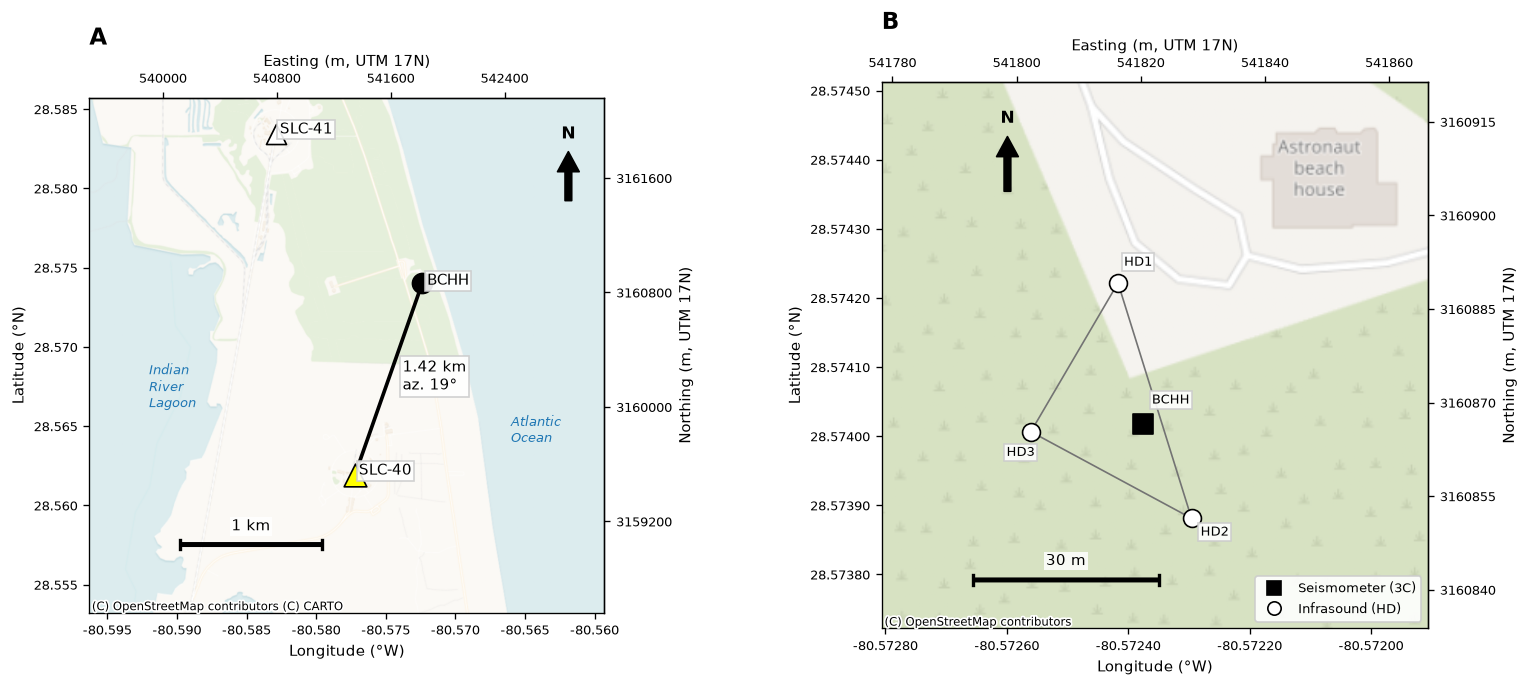

In [11]:
fig, axes = make_figure1(
    slc40=SLC40,
    slc41=SLC41,
    bchh=BCHH,
    bchh_sensors=bchh_sensors_df,
    geod=geod,
    ll_to_utm=ll_to_utm,
    utm_to_ll=utm_to_ll,
)

output_paths = save_figure(
    fig=fig,
    output_directory=FIGURE_DIR,
    filename_stem="fig01_slc40_bchh_location",
    extensions=("png", "pdf"),
    dpi=300,
)

print("Saved Figure 1:")
for path in output_paths:
    print(f"  {Path(path).resolve()}")

plt.show()


## Outputs

- `outputs/figures/fig01_slc40_bchh_location.png`
- `outputs/figures/fig01_slc40_bchh_location.pdf`

If only geometry metadata changes, rerun Notebook 02 and this notebook.
Instrument correction and downstream waveform measurements do not need to be
repeated.


# Part II — Key-event and catalogue figures


Read finalized products and generate publication figures. Scientific measurements are loaded from CSV rather than silently recalculated.


In [22]:

from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import Stream, UTCDateTime

from project_config import ensure_output_dirs

PATHS = ensure_output_dirs(PROJECT_ROOT)
DERIVED_DIR = PATHS["derived"]
FIGURE_DIR = PATHS["figures"]

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})


In [23]:

from obspy import read
from plotting import plot_key_event_waveforms

st_corr = read(str(DERIVED_DIR / "bchh_corrected_analysis_window.pkl"),
               format="PICKLE")
measurements = pd.read_csv(
    DERIVED_DIR / "key_event_pressure_measurements.csv"
)


## Initial second-stage failure


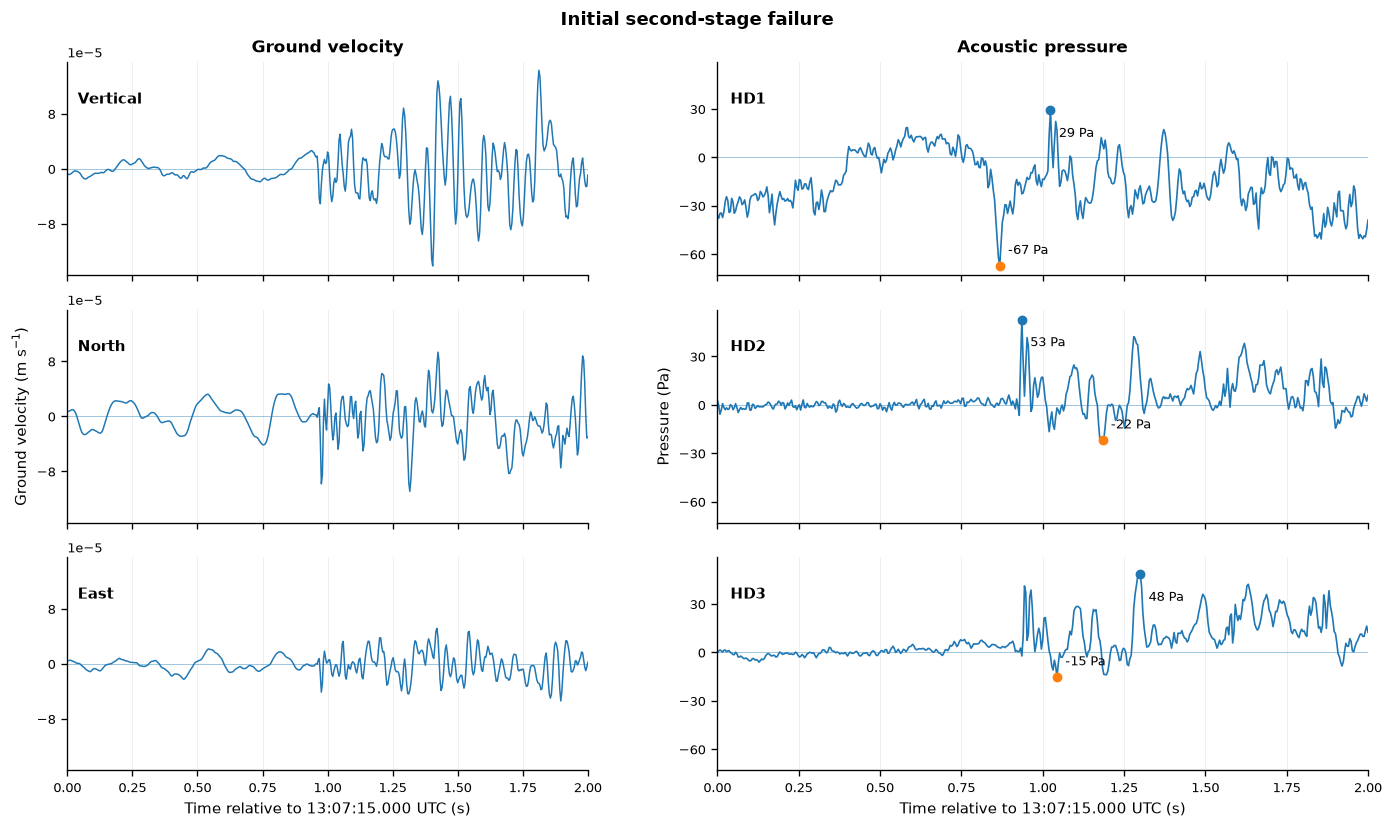

In [24]:

EXPLOSION_TIME = UTCDateTime("2016-09-01T13:07:12.080")
t0, t1 = EXPLOSION_TIME + 3.0 - 0.08, EXPLOSION_TIME + 5.0 - 0.08
st_event = st_corr.copy().trim(t0, t1)
event_results = measurements.loc[
    measurements["event"] == "Initial second-stage failure"
]
plot_key_event_waveforms(
    st_event,
    reference_time=t0,
    pressure_results=event_results,
    title="Initial second-stage failure",
    outfile=FIGURE_DIR / "second_stage_waveforms.png",
)
plt.show()


## Principal explosion


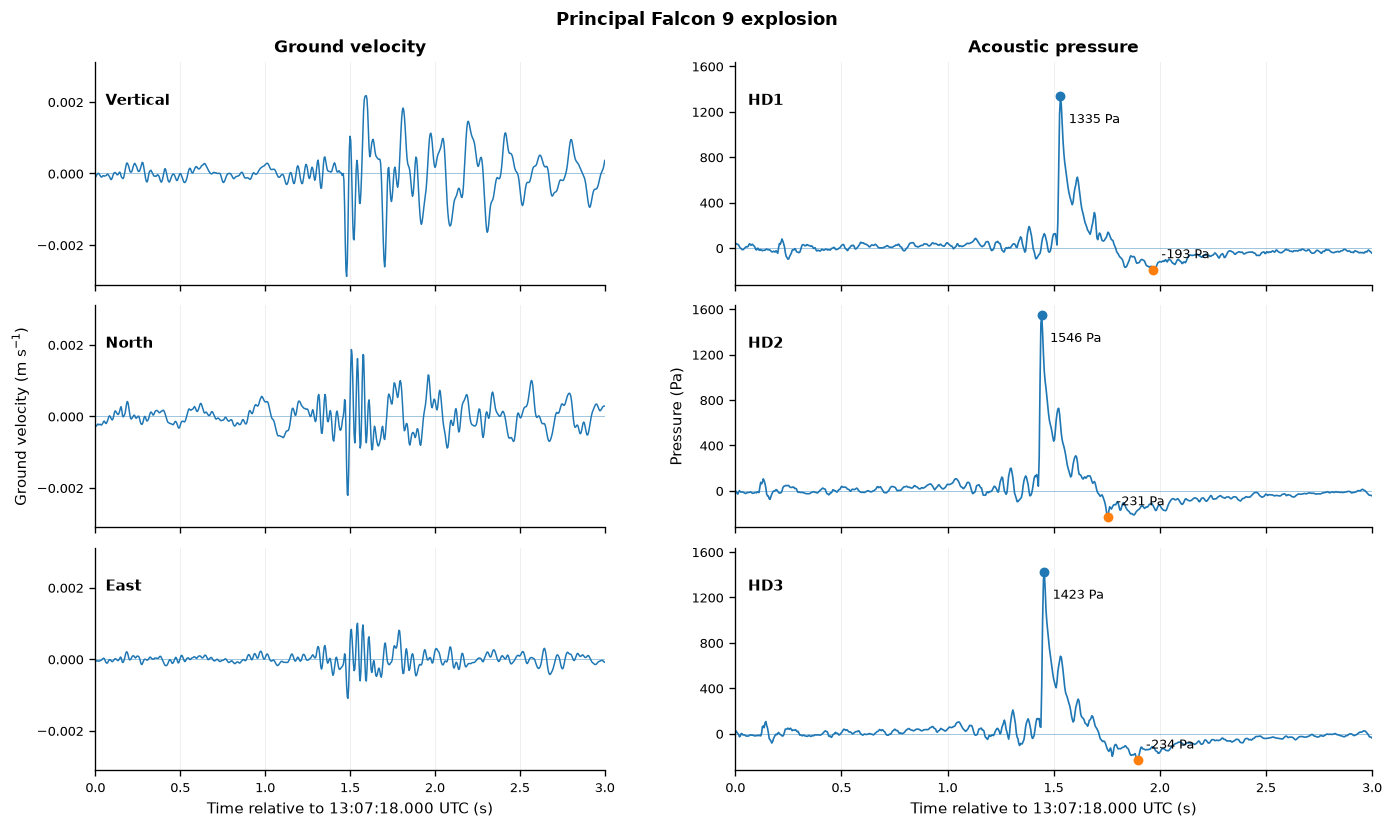

In [25]:

t0, t1 = EXPLOSION_TIME + 6.0 - 0.08, EXPLOSION_TIME + 9.0 - 0.08
st_event = st_corr.copy().trim(t0, t1)
event_results = measurements.loc[
    measurements["event"] == "Principal explosion"
]
plot_key_event_waveforms(
    st_event,
    reference_time=t0,
    pressure_results=event_results,
    title="Principal Falcon 9 explosion",
    outfile=FIGURE_DIR / "principal_explosion_waveforms.png",
)
plt.show()


## Capsule sequence


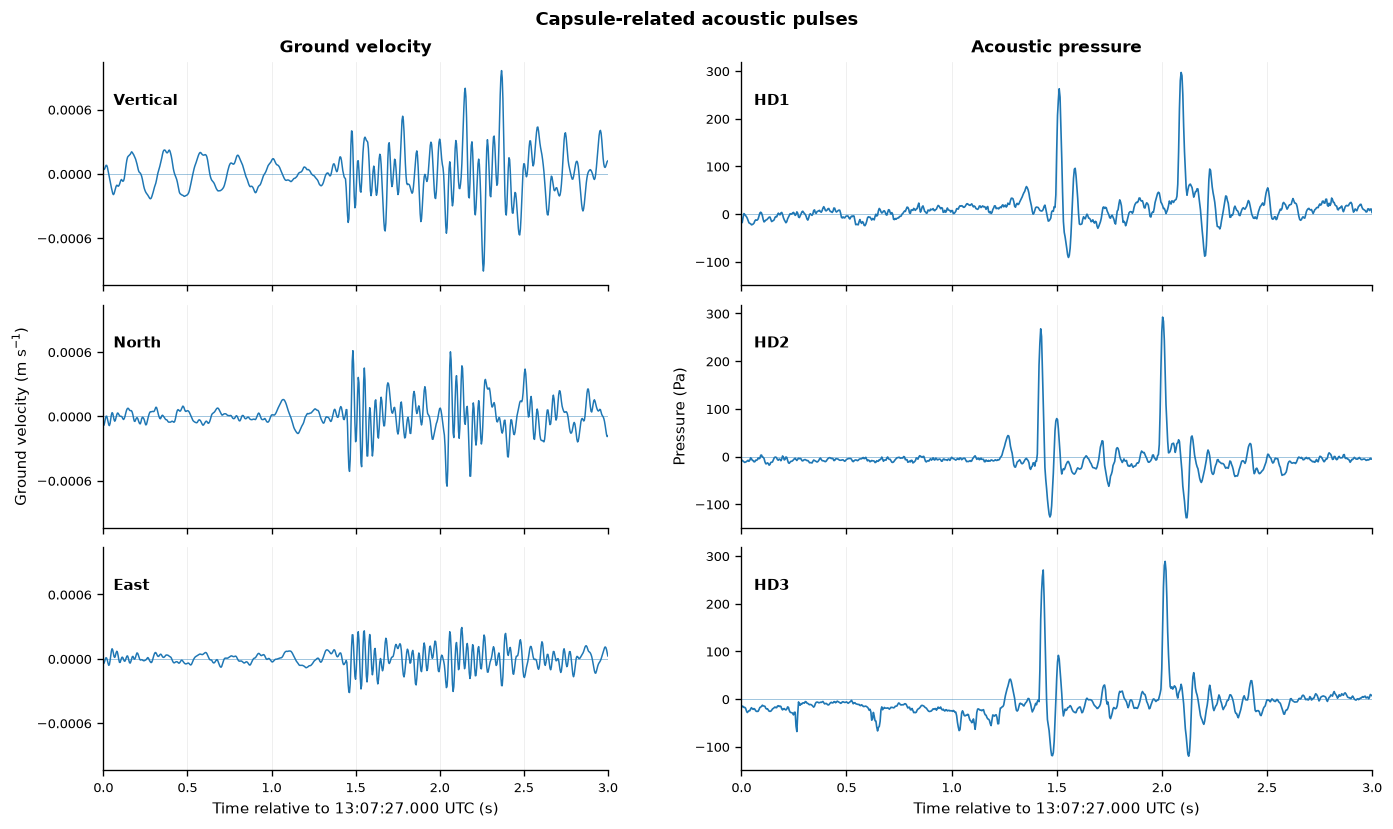

In [26]:

t0 = UTCDateTime("2016-09-01T13:07:27.0")
t1 = UTCDateTime("2016-09-01T13:07:30.0")
st_event = st_corr.copy().trim(t0, t1)
capsule_results = measurements.loc[
    measurements["event"].isin(["Capsule pulse 1", "Capsule pulse 2"])
]
# For a two-pulse figure, marker annotations should be added manually or by
# extending plotting.py to accept multiple measurement windows.
plot_key_event_waveforms(
    st_event,
    reference_time=t0,
    pressure_results=None,
    title="Capsule-related acoustic pulses",
    outfile=FIGURE_DIR / "capsule_waveforms.png",
    add_measurements=False,
)
plt.show()


## Array-result figures


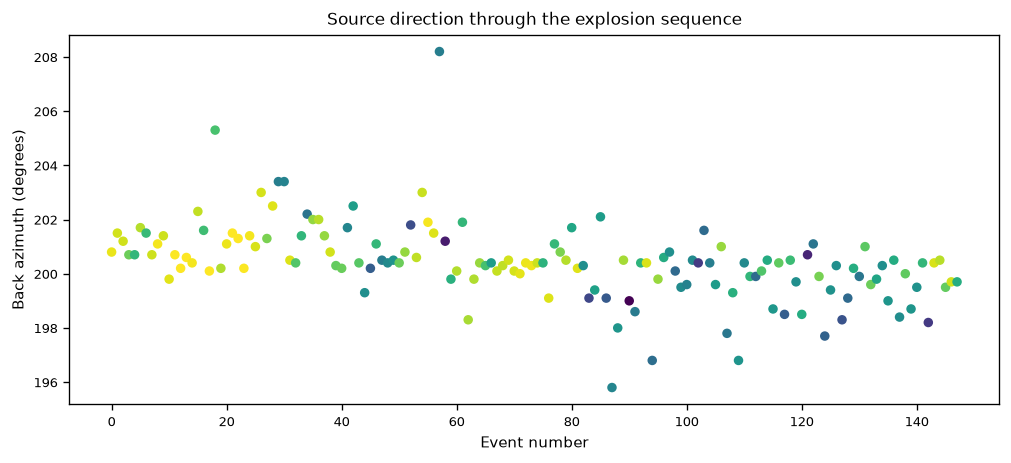

In [27]:

array_file = PROJECT_ROOT / "outputs" / "array_analysis_planar_refined" / "planar_array_results.csv"
if array_file.exists():
    array_results = pd.read_csv(array_file)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(
        np.arange(len(array_results)),
        array_results["best_back_azimuth_deg"],
        c=array_results["maximum_coherence_score"],
        s=22,
    )
    ax.set_xlabel("Event number")
    ax.set_ylabel("Back azimuth (degrees)")
    ax.set_title("Source direction through the explosion sequence")
    fig.savefig(
        FIGURE_DIR / "catalogue_back_azimuth.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("Run 05_planar_array_analysis.ipynb first.")
